# 🔑 Machine Learning Prerequisites
## Everything You Need to Know Before Building Neural Networks

---

> *"You don't need a PhD. You need the right mental models, built in the right order."*

---

### Who This Notebook Is For

This notebook is for anyone who wants to understand neural networks from first principles — but first wants to make sure the **foundational concepts** are solid.

These are not difficult ideas. They are just ideas that most tutorials assume you already know, which means beginners often hit a wall not because the deep learning is hard, but because nobody explained the prerequisites properly.

We fix that here.

By the end of this notebook you will understand:
- What data actually *looks like* to a machine learning model
- Why linear algebra (vectors and matrices) is the language of ML
- The key statistics concepts every practitioner uses daily
- What overfitting is, why it happens, and how to fight it
- What the different activation functions are and why we have several
- How the perceptron works — the single ancestor of all neural networks

### Roadmap

```
PART 1 ── Data & Features
           (what the model actually sees, feature types, normalisation)

PART 2 ── Linear Algebra for ML
           (vectors, matrices, dot products — why they matter)

PART 3 ── Probability & Statistics Essentials
           (distributions, mean, variance, the Gaussian)

PART 4 ── Overfitting, Underfitting & Generalisation
           (the bias-variance tradeoff, train/val/test splits)

PART 5 ── Activation Functions — A Complete Tour
           (Sigmoid, Tanh, ReLU, Leaky ReLU — compared side by side)

PART 6 ── The Perceptron
           (the grandparent of all neural networks, built from scratch)

PART 7 ── Summary Notes
           (everything condensed for your personal notebook)
```

Let's begin.


---
## Setup — Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(0)

# ── Consistent plot style ─────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#FAFAFA',
    'axes.facecolor'   : '#FAFAFA',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})

print("✅ Ready. Let's build the foundations.")

✅ Ready. Let's build the foundations.


---
# PART 1 — Data & Features

---

## 1.1 What Does a Machine Learning Model Actually See?

Here is something that surprises many beginners: a machine learning model does not see "a cat photo" or "a customer" or "a medical record."

It sees **a row of numbers. Nothing else.**

Everything in the world — images, text, audio, patient records — must be converted into a row of numbers before a model can process it. That row of numbers is called a **feature vector**.

### A Concrete Example: House Prices

Imagine you want to predict the sale price of a house. Each house might be described by:

| Feature | Example value | Type |
|---------|--------------|------|
| Square footage | 1,450 | Numerical (continuous) |
| Number of bedrooms | 3 | Numerical (discrete) |
| Distance to city centre (km) | 12.4 | Numerical (continuous) |
| Has a garden? | Yes / No | Categorical (binary) |
| Neighbourhood | Northside / Southside / Downtown | Categorical (multi-class) |
| Year built | 1987 | Numerical (can be continuous or treated as category) |

The model sees **one row per house**, where each column is a feature. A dataset with 1,000 houses is a table with 1,000 rows.

In the language of linear algebra (Part 2), this table is called a **matrix X**.

> **Key mental model:** Every training example is a point in a high-dimensional space. Each feature is one axis of that space. The model's job is to find patterns in that space.

---

## 1.2 Feature Types — Why They Need Different Treatment

Not all columns can be fed directly into a model. Some need pre-processing.

### Continuous Numerical Features
e.g. square footage = 1450, price = £320,000

These are ready to use — but they often have very different **scales**. A model might get confused if square footage (range: 400–5000) and distance in km (range: 0.5–30) are mixed without adjustment. We fix this with **normalisation** (see 1.3).

### Categorical Features
e.g. neighbourhood = "Northside"

Models cannot do maths with words. We convert categories to numbers using **one-hot encoding**:

```
"Northside"  →  [1, 0, 0]
"Southside"  →  [0, 1, 0]
"Downtown"   →  [0, 0, 1]
```

Each category becomes its own binary column. Only one is "1" at a time — hence "one hot".

### Binary Features
e.g. has_garden = Yes/No → encode as 1/0. Simple.

---

## 1.3 Normalisation and Standardisation — Why Scaling Matters

This is one of the most practically important things in ML, and one of the most commonly skipped.

**The problem:** Imagine your dataset has:
- Feature A: salary in Ugandan shillings → values around 3,000,000
- Feature B: age in years → values around 30

When gradient descent computes updates, Feature A's gradient will be **100,000× larger** than Feature B's. This causes wildly unstable training — one feature dominates and others are barely updated.

**The fix:** Scale all features to a comparable range before training.

### Method 1: Min-Max Normalisation (Scale to [0, 1])

$$x_{\text{norm}} = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

- Guarantees all values land in [0, 1]
- Good when you know the range of your data
- Sensitive to outliers (one extreme value compresses everything else)

### Method 2: Standardisation (Scale to mean=0, std=1)

$$x_{\text{std}} = \frac{x - \mu}{\sigma}$$

- Centres data around 0 with standard deviation 1
- Robust to outliers (no fixed range guarantee, but extreme values don't dominate)
- The most common choice in deep learning

The cell below demonstrates both and shows why they matter.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# PART 1: DATA SCALING — VISUALISING THE EFFECT
# ─────────────────────────────────────────────────────────────────

# ── Implementing the two scaling methods ─────────────────────────

def min_max_normalise(x):
    """Scales x to the range [0, 1]."""
    return (x - x.min()) / (x.max() - x.min())

def standardise(x):
    """Scales x to have mean=0 and standard deviation=1."""
    return (x - x.mean()) / x.std()


# ── Simulate two features with very different natural scales ──────
np.random.seed(1)
n = 200

# Feature A: salary-like, mean ~3,000,000, slightly skewed
feature_A = np.random.normal(3_000_000, 500_000, n)
feature_A = np.append(feature_A, [6_000_000, 6_500_000])  # add two outliers

# Feature B: age-like, mean ~35, tight range
feature_B = np.random.normal(35, 8, len(feature_A))

# Apply both scalings
A_mm = min_max_normalise(feature_A)
B_mm = min_max_normalise(feature_B)

A_std = standardise(feature_A)
B_std = standardise(feature_B)


# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Why Feature Scaling Matters", fontsize=14, fontweight='bold')

# Raw: the scale problem is obvious
ax = axes[0]
ax.scatter(feature_A, feature_B, alpha=0.5, s=20, color='#2471A3')
ax.set_title("Raw Features (unscaled)\nFeature A dominates completely",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Feature A (salary, ~3,000,000)", fontsize=9)
ax.set_ylabel("Feature B (age, ~35)", fontsize=9)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.grid(True, alpha=0.3)

# Min-Max: both in [0,1], but outliers compress the distribution
ax2 = axes[1]
ax2.scatter(A_mm, B_mm, alpha=0.5, s=20, color='#E67E22')
ax2.set_title("Min-Max Normalised\nBoth in [0,1] — note outlier effect",
              fontsize=10, fontweight='bold')
ax2.set_xlabel("Feature A (normalised)", fontsize=9)
ax2.set_ylabel("Feature B (normalised)", fontsize=9)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.axvline(0.85, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
ax2.annotate("Outliers compress\nmain distribution",
             xy=(0.75, 0.3), fontsize=8, color='red')
ax2.grid(True, alpha=0.3)

# Standardised: mean=0, std=1, more robust
ax3 = axes[2]
ax3.scatter(A_std, B_std, alpha=0.5, s=20, color='#27AE60')
ax3.axvline(0, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax3.axhline(0, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax3.set_title("Standardised\nMean=0, Std=1 — robust to outliers",
              fontsize=10, fontweight='bold')
ax3.set_xlabel("Feature A (standardised)", fontsize=9)
ax3.set_ylabel("Feature B (standardised)", fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_scaling.png', dpi=120, bbox_inches='tight')
plt.show()


# ── Numeric summary ───────────────────────────────────────────────
print("Feature A (raw)          — mean: {:>12,.0f}   std: {:>10,.0f}".format(
    feature_A.mean(), feature_A.std()))
print("Feature A (min-max)      — mean: {:>12.4f}   std: {:>10.4f}".format(
    A_mm.mean(), A_mm.std()))
print("Feature A (standardised) — mean: {:>12.4f}   std: {:>10.4f}".format(
    A_std.mean(), A_std.std()))
print()
print("📖 After standardisation, both features have the same mean (0) and")
print("   the same standard deviation (1). Gradient descent treats them equally.")

---

## 1.4 One-Hot Encoding — Converting Categories to Numbers


In [ ]:
# ─────────────────────────────────────────────────────────────────
# ONE-HOT ENCODING — A CONCRETE DEMONSTRATION
# ─────────────────────────────────────────────────────────────────

# Imagine a dataset of 6 houses, each in one of 3 neighbourhoods.
neighbourhoods = ['Northside', 'Downtown', 'Southside', 'Northside', 'Downtown', 'Southside']

# Step 1: Get unique categories
categories = sorted(set(neighbourhoods))   # ['Downtown', 'Northside', 'Southside']
cat_to_idx = {cat: i for i, cat in enumerate(categories)}

print("Categories found:", categories)
print("Mapping:", cat_to_idx)
print()

# Step 2: Build the one-hot matrix
n_examples = len(neighbourhoods)
n_categories = len(categories)

one_hot = np.zeros((n_examples, n_categories), dtype=int)
for row_idx, neighbourhood in enumerate(neighbourhoods):
    col_idx = cat_to_idx[neighbourhood]
    one_hot[row_idx, col_idx] = 1    # set a single 1 in the correct column

print("Original labels:  ", neighbourhoods)
print()
print("One-Hot Encoded Matrix (rows = examples, columns = categories):")
print(f"{'':15}  {'Downtown':>10}  {'Northside':>10}  {'Southside':>10}")
print("─" * 52)
for label, row in zip(neighbourhoods, one_hot):
    print(f"{label:15}  {row[0]:>10}  {row[1]:>10}  {row[2]:>10}")

print()
print("📖 Key properties of one-hot encoding:")
print("  ✔  Every row has exactly one '1' — hence 'one hot'")
print("  ✔  No ordering is implied. 'Northside' ≠ more or less than 'Downtown'")
print("  ✔  If N categories, we create N new binary columns")
print("  ⚠  Problem: if you have 10,000 categories (e.g. postcodes),")
print("     one-hot creates 10,000 columns! This is called 'high cardinality'")
print("     and is handled with embeddings (a deep learning technique).")

---
# PART 2 — Linear Algebra for ML

---

## 2.1 Why Linear Algebra?

Almost everything in machine learning is, at its core, **matrix multiplication**.

When a neural network processes an input and produces a prediction, it is doing a series of matrix operations. When you train on a batch of 64 examples simultaneously, the data for all 64 is stacked into a matrix. When GPUs make deep learning fast, it's because they are extremely good at matrix multiplication.

You do not need to master linear algebra — you need three concepts:
1. What a **vector** is
2. What a **matrix** is
3. What a **dot product** / **matrix multiplication** does

---

## 2.2 Vectors — One Data Point

A **vector** is just a list of numbers with a direction.

In ML, **one training example** is represented as a vector. For the house price example:

$$\vec{x} = [1450, \; 3, \; 12.4, \; 1, \; 0, \; 1, \; 1987]$$

That's 7 numbers — 7 features. We say this vector lives in **7-dimensional space**.

Geometrically, you can picture a 2D vector as an arrow on a graph. The arrow points to the coordinates (x₁, x₂).

---

## 2.3 Matrices — Many Data Points Together

A **matrix** is a 2D grid of numbers — rows and columns.

In ML, we stack our training examples into a matrix **X** where:
- Each **row** is one training example
- Each **column** is one feature

If you have 1,000 houses and 7 features, X has shape **(1000, 7)**.

The **weight matrix W** of a neural network layer also has a specific shape that controls what the layer does.

---

## 2.4 The Dot Product — The Core Operation

The **dot product** of two vectors is one of the most important operations in all of ML.

$$\vec{a} \cdot \vec{b} = \sum_{i} a_i \cdot b_i = a_1 b_1 + a_2 b_2 + \ldots + a_n b_n$$

**Intuition:** The dot product measures *how aligned* two vectors are.

- If $\vec{a}$ and $\vec{b}$ point in the same direction: dot product is **large and positive** ✅
- If they are perpendicular: dot product is **zero** ↔
- If they point opposite directions: dot product is **negative** ❌

**Why does this matter for ML?**

When a neuron computes `Z = X · W`, it is asking: *"How much does this input pattern align with the pattern this neuron has learned to look for?"* A large positive Z means strong alignment — the pattern was found.

---

## 2.5 Matrix Multiplication — Batch Processing

Matrix multiplication extends the dot product to work on many vectors at once.

If X has shape **(batch_size, input_features)** and W has shape **(input_features, output_neurons)**, then:

$$Z = X \cdot W \quad \text{has shape } (\text{batch\_size}, \text{output\_neurons})$$

This one line computes the dot product of **every input example with every neuron's weight vector simultaneously**. That's why matrix multiplication is so central — it's the engine that powers an entire batch of computations in one go.


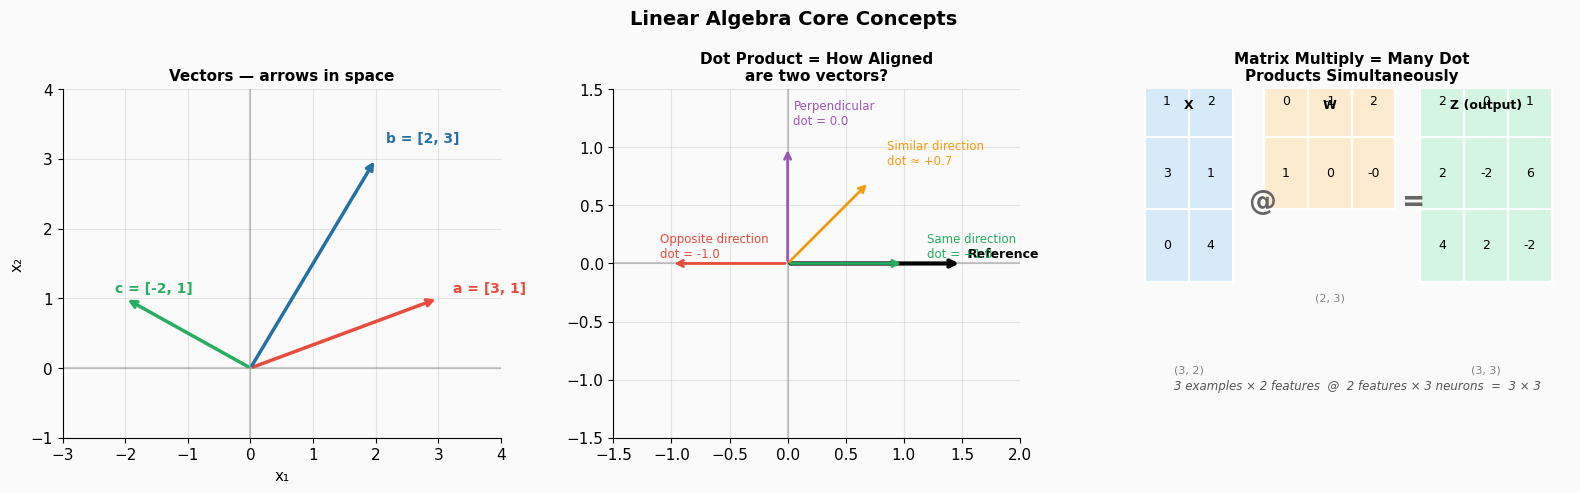

📖 The matrix multiply Z = X @ W is the single most important
   operation in deep learning. Every layer is one of these.

X shape: (3, 2)   (3 training examples, 2 features each)
W shape: (2, 3)   (weights for 3 neurons, 2 inputs each)
Z shape: (3, 3)   (3 examples × 3 neurons = one score per neuron per example)


In [2]:
# ─────────────────────────────────────────────────────────────────
# PART 2: LINEAR ALGEBRA VISUALISED
# ─────────────────────────────────────────────────────────────────

# ── Section A: Vectors and the dot product ────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Linear Algebra Core Concepts", fontsize=14, fontweight='bold')

# --- Plot 1: Vectors as arrows ---
ax = axes[0]
vectors = {
    'a = [3, 1]'  : (np.array([3, 1]),  '#E74C3C'),
    'b = [2, 3]'  : (np.array([2, 3]),  '#2471A3'),
    'c = [-2, 1]' : (np.array([-2, 1]), '#27AE60'),
}
for label, (vec, col) in vectors.items():
    ax.annotate("", xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax.text(vec[0]*1.08, vec[1]*1.08, label, color=col, fontsize=10, fontweight='bold')

ax.set_xlim(-3, 4)
ax.set_ylim(-1, 4)
ax.axhline(0, color='grey', alpha=0.4)
ax.axvline(0, color='grey', alpha=0.4)
ax.grid(True, alpha=0.3)
ax.set_title("Vectors — arrows in space", fontsize=11, fontweight='bold')
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")

# --- Plot 2: Dot product = alignment ---
ax2 = axes[1]
base_vec = np.array([1, 0])   # reference: pointing right
test_vecs = [
    ([1, 0],   '#27AE60', 'Same direction\ndot = +1.0'),
    ([0.7, 0.7], '#F39C12', 'Similar direction\ndot ≈ +0.7'),
    ([0, 1],   '#9B59B6', 'Perpendicular\ndot = 0.0'),
    ([-1, 0],  '#E74C3C', 'Opposite direction\ndot = -1.0'),
]

ax2.annotate("", xy=(1.5, 0), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='black', lw=3))
ax2.text(1.55, 0.05, 'Reference', fontsize=9, fontweight='bold')

for vec, col, label in test_vecs:
    v = np.array(vec, dtype=float)
    dot = float(np.dot(base_vec, v / np.linalg.norm(v)))
    ax2.annotate("", xy=v, xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax2.text(v[0]*1.15 + 0.05, v[1]*1.15 + 0.05,
             label, color=col, fontsize=8.5)

ax2.set_xlim(-1.5, 2.0)
ax2.set_ylim(-1.5, 1.5)
ax2.axhline(0, color='grey', alpha=0.4)
ax2.axvline(0, color='grey', alpha=0.4)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
ax2.set_title("Dot Product = How Aligned\nare two vectors?", fontsize=11, fontweight='bold')

# --- Plot 3: Matrix multiplication as batch dot products ---
ax3 = axes[2]
ax3.axis('off')

ax3.set_title("Matrix Multiply = Many Dot\nProducts Simultaneously",
              fontsize=11, fontweight='bold')

# Visual of X @ W → Z
X_demo = np.array([[1, 2], [3, 1], [0, 4]])       # 3 examples, 2 features
W_demo = np.array([[0.5, -1, 2], [1, 0.5, -0.5]]) # 2 features → 3 neurons
Z_demo = X_demo @ W_demo                           # result: 3 examples × 3 neurons

def draw_matrix(ax, mat, x0, y0, cell_w=0.35, cell_h=0.3,
                colour='#AED6F1', label=''):
    rows, cols = mat.shape
    for r in range(rows):
        for c in range(cols):
            rect = plt.Rectangle((x0 + c*cell_w, y0 - r*cell_h),
                                  cell_w, cell_h,
                                  facecolor=colour, edgecolor='white', lw=1.5)
            ax3.add_patch(rect)
            ax3.text(x0 + c*cell_w + cell_w/2, y0 - r*cell_h + cell_h/2,
                     f"{mat[r,c]:.0f}", ha='center', va='center', fontsize=9)
    ax3.text(x0 + cols*cell_w/2, y0 + 0.12, label,
             ha='center', fontsize=9, fontweight='bold')
    ax3.text(x0 + cols*cell_w/2, y0 - rows*cell_h - 0.08,
             f"{mat.shape}", ha='center', fontsize=8, color='grey')

draw_matrix(ax3, X_demo, 0.0, 0.9, colour='#D6EAF8', label='X')
ax3.text(0.82, 0.6, '@', fontsize=20, fontweight='bold', color='#666')
draw_matrix(ax3, W_demo, 0.95, 0.9, colour='#FDEBD0', label='W')
ax3.text(2.05, 0.6, '=', fontsize=20, fontweight='bold', color='#666')
draw_matrix(ax3, Z_demo, 2.2, 0.9, colour='#D5F5E3', label='Z (output)')

ax3.text(1.7, -0.15,
         "3 examples × 2 features  @  2 features × 3 neurons  =  3 × 3",
         ha='center', fontsize=8.5, style='italic', color='#555')

ax3.set_xlim(-0.1, 3.4)
ax3.set_ylim(-0.35, 1.1)

plt.tight_layout()
plt.savefig('linear_algebra.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 The matrix multiply Z = X @ W is the single most important")
print("   operation in deep learning. Every layer is one of these.")
print()
print(f"X shape: {X_demo.shape}   (3 training examples, 2 features each)")
print(f"W shape: {W_demo.shape}   (weights for 3 neurons, 2 inputs each)")
print(f"Z shape: {Z_demo.shape}   (3 examples × 3 neurons = one score per neuron per example)")

---
# PART 3 — Probability & Statistics Essentials

---

## 3.1 Why Statistics?

A machine learning model is, at its heart, a **statistical model**. It doesn't learn hard rules — it learns patterns and probabilities from data. Understanding a few statistical concepts is essential for reasoning about your model's behaviour.

We cover the five most important ones.

---

## 3.2 Mean and Variance — Describing a Distribution

**Mean (average)** — the centre of gravity of a dataset:
$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$$

**Variance** — how spread out the data is:
$$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2$$

**Standard Deviation (σ)** — the square root of variance. Same units as the data.

Intuition:
- Low variance → data points are clustered tightly around the mean
- High variance → data is widely spread out

In ML: variance in your training data affects how confidently a model can learn patterns.

---

## 3.3 The Normal (Gaussian) Distribution — Why It's Everywhere

The **Gaussian (Normal) distribution** is the famous bell curve. It is defined entirely by its mean (μ) and standard deviation (σ):

$$p(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Why does it appear everywhere?** The **Central Limit Theorem** tells us that when you average many independent random things (measurement errors, biological traits, financial noise), the average tends toward a Gaussian — regardless of the original distribution.

**In ML, the Gaussian appears in:**
- Weight initialisation (we draw initial weights from a Gaussian)
- Data distributions (many real-world features are roughly Gaussian)
- Loss analysis and model uncertainty

---

## 3.4 Correlation — Does One Feature Predict Another?

**Correlation** measures the linear relationship between two variables. It ranges from **-1 to +1**:

| Correlation | Meaning |
|:-----------:|:--------|
| **+1** | Perfect positive relationship — as x goes up, y goes up exactly |
| **0** | No linear relationship |
| **-1** | Perfect negative relationship — as x goes up, y goes down exactly |

**Why it matters in ML:**
- Highly correlated features add redundant information — they slow training without helping
- Checking correlations between features (a **correlation matrix**) is a standard first step in **Exploratory Data Analysis (EDA)**


In [ ]:
# ─────────────────────────────────────────────────────────────────
# PART 3: STATISTICS VISUALISED
# ─────────────────────────────────────────────────────────────────

np.random.seed(42)
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Statistics Essentials for ML", fontsize=14, fontweight='bold')


# ── Plot 1: Mean and Variance ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

data_tight = np.random.normal(50, 3, 500)    # low variance
data_wide  = np.random.normal(50, 15, 500)   # high variance

ax1.hist(data_tight, bins=40, alpha=0.7, color='#2471A3', density=True,
         label=f'Low σ (σ=3)')
ax1.hist(data_wide,  bins=40, alpha=0.5, color='#E74C3C', density=True,
         label=f'High σ (σ=15)')
ax1.axvline(50, color='black', linestyle='--', lw=1.5, label='Mean μ=50')
ax1.set_title("Mean & Variance", fontsize=11, fontweight='bold')
ax1.set_xlabel("Value")
ax1.set_ylabel("Density")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)


# ── Plot 2: The Gaussian — different μ and σ ──────────────────────
ax2 = fig.add_subplot(gs[0, 1])

x = np.linspace(-10, 15, 400)
gaussians = [
    (0,  1,   '#1A5276', 'μ=0, σ=1  (standard normal)'),
    (5,  1,   '#27AE60', 'μ=5, σ=1  (shifted right)'),
    (0,  2.5, '#E74C3C', 'μ=0, σ=2.5 (wider)'),
]

for mu, sigma, col, label in gaussians:
    y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    ax2.plot(x, y, color=col, linewidth=2.5, label=label)
    ax2.axvline(mu, color=col, linestyle=':', alpha=0.5, lw=1)

ax2.set_title("The Gaussian Distribution", fontsize=11, fontweight='bold')
ax2.set_xlabel("x")
ax2.set_ylabel("Probability density")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)


# ── Plot 3: The 68-95-99.7 rule ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

x_std = np.linspace(-4, 4, 400)
y_std = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_std**2)

ax3.plot(x_std, y_std, 'k-', linewidth=2)

fills = [(-1, 1, '#D6EAF8', '68%: within 1σ'),
         (-2, 2, '#AED6F1', '95%: within 2σ'),
         (-3, 3, '#85C1E9', '99.7%: within 3σ')]
for lo, hi, col, label in reversed(fills):
    mask = (x_std >= lo) & (x_std <= hi)
    ax3.fill_between(x_std[mask], y_std[mask], alpha=0.9, color=col, label=label)

for s in [1, 2, 3]:
    ax3.axvline(s,  color='grey', linestyle='--', lw=0.8)
    ax3.axvline(-s, color='grey', linestyle='--', lw=0.8)
    ax3.text(s + 0.05, 0.38, f'+{s}σ', fontsize=8, color='grey')

ax3.set_title("The 68-95-99.7 Rule", fontsize=11, fontweight='bold')
ax3.set_xlabel("Standard deviations from mean")
ax3.set_ylabel("Probability density")
ax3.legend(fontsize=8, loc='upper left')
ax3.grid(True, alpha=0.3)


# ── Plot 4: Correlation demo ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
ax4.axis('off')

corr_examples = [
    (0.95,  '#27AE60', 'Strong Positive (r ≈ 0.95)\n e.g. height & shoe size'),
    (0.3,   '#F39C12', 'Weak Positive (r ≈ 0.3)\n e.g. hours of sleep & mood'),
    (0.0,   '#9B59B6', 'No Correlation (r ≈ 0.0)\n e.g. shoe size & IQ'),
    (-0.85, '#E74C3C', 'Strong Negative (r ≈ -0.85)\n e.g. altitude & temperature'),
]

inner_axes_positions = [(0.04, 0.06, 0.18, 0.85),
                        (0.27, 0.06, 0.18, 0.85),
                        (0.50, 0.06, 0.18, 0.85),
                        (0.73, 0.06, 0.18, 0.85)]

ax4.set_title("Correlation — Four Cases", fontsize=11, fontweight='bold', pad=10)

for pos, (r_target, col, title) in zip(inner_axes_positions, corr_examples):
    inner_ax = fig.add_axes(
        [ax4.get_position().x0 + pos[0] * ax4.get_position().width,
         ax4.get_position().y0 + pos[1] * ax4.get_position().height,
         pos[2] * ax4.get_position().width,
         pos[3] * ax4.get_position().height])
    
    n_pts = 150
    x_base = np.random.randn(n_pts)
    noise  = np.sqrt(1 - r_target**2) * np.random.randn(n_pts)
    y_base = r_target * x_base + noise
    
    inner_ax.scatter(x_base, y_base, alpha=0.4, s=12, color=col)
    inner_ax.set_title(title, fontsize=8, fontweight='bold', color=col, pad=3)
    inner_ax.tick_params(labelsize=7)
    inner_ax.set_facecolor('#FAFAFA')
    inner_ax.grid(True, alpha=0.2)
    for spine in ['top','right']:
        inner_ax.spines[spine].set_visible(False)

plt.savefig('statistics_essentials.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 The 68-95-99.7 rule is how we reason about what values are 'normal'")
print("   vs. 'outliers'. An outlier is usually defined as > 3σ from the mean.")

---
# PART 4 — Overfitting, Underfitting & Generalisation

---

## 4.1 The Core Problem: You Train on One Dataset, Deploy on Another

Here is the fundamental tension in machine learning:

> **You train your model on a fixed dataset. But the whole point is that it works well on new, unseen data.**

A model that just memorises the training data is useless — it can't handle anything new. A model that doesn't train enough can't even handle the training data. The goal is a model that **generalises** — it has learned the underlying pattern, not the specific examples.

This balance is described by three states:

---

## 4.2 Underfitting — The Model Is Too Simple

**What it is:** The model hasn't learned enough. It performs badly on both training data and new data.

**Analogy:** A student who studied for 20 minutes and couldn't answer any questions — even the practice problems.

**Signs:** Training loss is high. Validation loss is also high.

**Fixes:** Use a bigger model, train for longer, add more features.

---

## 4.3 Overfitting — The Model Memorised Instead of Learning

**What it is:** The model has learned the training data *too* well — including all its noise and random quirks. It performs brilliantly on training data, but poorly on anything new.

**Analogy:** A student who memorised every practice exam question word-for-word — but fails a test with slightly different wording because they never understood the underlying concepts.

**Signs:** Training loss is very low. Validation loss is much higher (the gap is the overfitting).

**Fixes:** Fewer parameters, more training data, regularisation (see below), early stopping.

---

## 4.4 Train / Validation / Test Splits — How We Detect These Problems

We split our data into three parts:

| Split | Typical % | Purpose |
|-------|:---------:|:--------|
| **Training set** | 70% | The model learns on this |
| **Validation set** | 15% | We check performance on this *during* training to detect overfitting |
| **Test set** | 15% | We use this **once**, at the very end, to report final performance |

**Why not just one split (train/test)?**
Because if you tune your model based on test set performance, you've implicitly trained on the test set. The test set must remain untouched until the very end — it simulates the "real world" you haven't seen yet.

---

## 4.5 Regularisation — A Leash on the Model's Complexity

**Regularisation** is any technique that discourages a model from becoming too complex, reducing overfitting.

The two most common are:

**L2 Regularisation (Weight Decay):** Add the sum of squared weights to the loss:
$$L_{\text{total}} = L_{\text{original}} + \lambda \sum w_i^2$$

This penalises large weights. The model is forced to spread its reliance across many small weights rather than depending heavily on a few — which tends to produce smoother, more generalisable solutions.

**Dropout:** During training, randomly "turn off" a fraction of neurons at each step. This prevents neurons from co-adapting and forces the network to learn redundant representations.

$\lambda$ is the **regularisation strength** — how hard you pull the leash. Too tight and the model underfits; too loose and overfitting continues.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# PART 4: OVERFITTING & UNDERFITTING — VISUALISED WITH POLYNOMIAL FITTING
# ─────────────────────────────────────────────────────────────────

# We'll generate some data from a simple sine wave + noise, then
# fit polynomials of different degrees to show under/over/just-right fitting.

np.random.seed(7)

# True underlying function: a sine wave
def true_function(x):
    return np.sin(x * 1.5)

# Generate training data: sample the sine wave + add noise
n_train = 20
x_train = np.sort(np.random.uniform(0, 4, n_train))
y_train = true_function(x_train) + np.random.normal(0, 0.3, n_train)

# Generate test data (new, unseen points)
n_test = 100
x_test = np.linspace(0, 4, n_test)
y_test = true_function(x_test)

# Fit polynomials of degree 1, 4, and 15
degrees = [(1, 'Underfitting\n(degree 1 — too simple)', '#E74C3C'),
           (4, 'Just Right\n(degree 4 — good fit)', '#27AE60'),
           (15, 'Overfitting\n(degree 15 — too complex)', '#8E44AD')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Underfitting vs. Just Right vs. Overfitting",
             fontsize=14, fontweight='bold')

for ax, (deg, title, col) in zip(axes, degrees):
    # Fit the polynomial to training data
    coeffs = np.polyfit(x_train, y_train, deg)
    p = np.poly1d(coeffs)
    
    # Evaluate on a dense grid
    x_dense = np.linspace(0, 4, 300)
    y_dense = p(x_dense)
    
    # Compute errors
    train_loss = np.mean((p(x_train) - y_train)**2)
    test_loss  = np.mean((p(x_test)  - y_test)**2)
    
    # Plot
    ax.plot(x_dense, np.sin(x_dense * 1.5), 'k--', lw=1.5, alpha=0.5,
            label='True function (unknown)')
    ax.scatter(x_train, y_train, color='#1A5276', s=40, zorder=5,
               label='Training data')
    ax.plot(x_dense, y_dense, color=col, lw=2.5, label='Model fit')
    
    ax.set_title(title, fontsize=11, fontweight='bold', color=col)
    ax.set_xlabel("x", fontsize=10)
    ax.set_ylabel("y", fontsize=10)
    ax.set_ylim(-3, 3)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Loss box
    gap = test_loss - train_loss
    ax.text(0.05, 0.07,
            f"Train loss: {train_loss:.3f}\nTest  loss: {test_loss:.3f}\nGap:  {gap:.3f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=col, lw=1.5))

plt.tight_layout()
plt.savefig('overfitting.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 What to notice:")
print("  RED   (degree 1):  The model is a straight line. It can't capture the curve.")
print("                     Both train AND test loss are high. This is underfitting.")
print()
print("  GREEN (degree 4):  Smooth curve that follows the true shape well.")
print("                     Train ≈ test loss. This is good generalisation.")
print()
print("  PURPLE (degree 15): The model bends through every training point exactly.")
print("                      Train loss is tiny — but test loss is huge. Overfitting.")
print("                      It memorised noise instead of learning the pattern.")

In [ ]:
# ─────────────────────────────────────────────────────────────────
# VISUALISING THE TRAIN / VALIDATION LOSS DIVERGENCE
# This is the single most important plot in a training run.
# When you see these two lines diverge, your model is overfitting.
# ─────────────────────────────────────────────────────────────────

# Simulating a typical training curve where overfitting kicks in around epoch 40
epochs = np.arange(1, 101)

train_loss = 1.0 * np.exp(-0.05 * epochs) + 0.04 + np.random.normal(0, 0.01, 100)
val_loss   = 1.0 * np.exp(-0.04 * epochs) + 0.12 \
             + 0.0015 * np.maximum(0, epochs - 40) \
             + np.random.normal(0, 0.015, 100)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(epochs, train_loss, color='#2471A3', lw=2.5, label='Training loss')
ax.plot(epochs, val_loss,   color='#E74C3C', lw=2.5, label='Validation loss')

ax.axvline(40, color='grey', linestyle='--', lw=1.5, alpha=0.7)
ax.text(41, 0.42, 'Overfitting\nbegins here →', fontsize=9, color='grey')

# Shade the generalisation gap
ax.fill_between(epochs[40:], train_loss[40:], val_loss[40:],
                alpha=0.15, color='#E74C3C', label='Generalisation gap (overfitting zone)')

# Annotate the ideal stopping point
best_epoch = np.argmin(val_loss) + 1
ax.scatter(best_epoch, val_loss[best_epoch-1], s=200, color='#27AE60',
           zorder=5, label=f'Best model (epoch {best_epoch})')

ax.set_title("Training vs Validation Loss — Detecting Overfitting\n"
             "(Real training always shows this shape if you go long enough)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('train_val_loss.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 This is the most important plot you'll produce during training.")
print(f"   Save the model at the point where validation loss is LOWEST — epoch ~{best_epoch}.")
print("   After that point, training loss keeps falling but the model gets WORSE on new data.")
print("   Stopping at the optimal point is called 'Early Stopping'.")

---
# PART 5 — Activation Functions: A Complete Tour

---

## 5.1 What Is an Activation Function and Why Do We Need One?

A neural network layer computes `Z = X·W + B`. This is a **linear** operation — a linear combination of inputs.

Here is the critical insight:

> **If you stack 10 linear layers, the result is still just one linear layer.**

That's because: `Linear(Linear(x)) = Linear(x)`. No matter how many you stack, you cannot represent anything non-linear.

But the real world is non-linear. House prices don't just increase linearly with size — they level off. Disease risk doesn't scale linearly with age. Images are non-linear by nature.

**An activation function introduces non-linearity** after each linear step. Now `f(Linear(f(Linear(x))))` is genuinely more expressive than any single linear function. This is what allows neural networks to model complex, curved patterns.

---

## 5.2 The Four Major Activation Functions

### Sigmoid — σ(z) = 1 / (1 + e⁻ᶻ)
- **Output range:** (0, 1)
- **Use case:** Binary classification output layers (the output is a probability)
- **Problem:** Gradients become nearly zero for very large or very small z — **vanishing gradient problem**. Rarely used in hidden layers of deep networks now.

### Tanh — tanh(z) = (eᶻ - e⁻ᶻ) / (eᶻ + e⁻ᶻ)
- **Output range:** (-1, +1)
- **Use case:** Hidden layers of RNNs and some other contexts
- **Advantage over Sigmoid:** Zero-centred output — gradients are not always positive, which helps training. Still suffers from vanishing gradients at extremes.

### ReLU — max(0, z)
- **Output range:** [0, ∞)
- **Use case:** Hidden layers of almost all modern neural networks
- **Why it wins:** Extremely simple to compute. Does not saturate for positive z — gradient is always 1 (or 0). Trains very fast.
- **Problem:** **Dead neurons** — if z is always negative, the gradient is always 0 and that neuron never learns.

### Leaky ReLU — max(0.01z, z)
- **Output range:** (-∞, +∞)
- **Use case:** Drop-in replacement for ReLU when dead neurons are a concern
- **Fix:** Instead of zero for negative z, gives a tiny slope (0.01z) — so neurons can still receive a gradient and recover.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# PART 5: ACTIVATION FUNCTIONS — FULL COMPARISON
# ─────────────────────────────────────────────────────────────────

# ── Implement all four activation functions and their derivatives ─

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)   # max is 0.25 at z=0

def tanh_act(z):
    return np.tanh(z)

def tanh_grad(z):
    return 1 - np.tanh(z)**2   # max is 1.0 at z=0

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)  # 1 if z>0, else 0

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_grad(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)


# ── Plot both function and derivative for all four ────────────────
z = np.linspace(-5, 5, 400)

activations = [
    ('Sigmoid  σ(z)',  sigmoid,      sigmoid_grad,      '#E74C3C',  '(0, 1)'),
    ('Tanh',          tanh_act,      tanh_grad,         '#2471A3',  '(-1, 1)'),
    ('ReLU',          relu,          relu_grad,         '#27AE60',  '[0, ∞)'),
    ('Leaky ReLU',    leaky_relu,    leaky_relu_grad,   '#8E44AD',  '(-∞, ∞)'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Activation Functions: Output and Gradient",
             fontsize=14, fontweight='bold')

for col_idx, (name, func, grad_func, col, output_range) in enumerate(activations):
    # Top row: the function itself
    ax = axes[0, col_idx]
    y = func(z)
    ax.plot(z, y, color=col, lw=2.5)
    ax.axhline(0, color='grey', alpha=0.4, lw=1)
    ax.axvline(0, color='grey', alpha=0.4, lw=1)
    ax.set_title(f"{name}\nOutput range: {output_range}",
                 fontsize=10, fontweight='bold', color=col)
    ax.set_xlabel("z (pre-activation)", fontsize=9)
    ax.set_ylabel("f(z)", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)
    
    # Bottom row: the gradient (derivative)
    ax2 = axes[1, col_idx]
    dy = grad_func(z)
    ax2.plot(z, dy, color=col, lw=2.5, linestyle='--')
    ax2.axhline(0, color='grey', alpha=0.4, lw=1)
    ax2.axvline(0, color='grey', alpha=0.4, lw=1)
    
    max_grad = dy.max()
    ax2.set_title(f"Gradient of {name}\nMax gradient: {max_grad:.2f}",
                  fontsize=10, color='#555')
    ax2.set_xlabel("z (pre-activation)", fontsize=9)
    ax2.set_ylabel("f'(z)", fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(-5, 5)
    
    # Annotate vanishing gradient zones
    if name in ('Sigmoid  σ(z)', 'Tanh'):
        ax2.fill_between(z[z < -2], dy[z < -2], alpha=0.3, color='red')
        ax2.fill_between(z[z > 2],  dy[z > 2],  alpha=0.3, color='red')
        ax2.text(-4.5, max_grad * 0.5, 'Vanishing\ngradient\nzone',
                 fontsize=7, color='red', ha='center')

axes[1, 2].fill_between(z[z < 0], 0, dy[z < 0], alpha=0.3, color='orange')
axes[1, 2].text(-3.5, 0.4, 'Dead neuron\nzone (grad=0)',
                fontsize=7, color='darkorange', ha='center')

axes[1, 3].fill_between(z[z < 0], 0, leaky_relu_grad(z)[z < 0],
                        alpha=0.3, color='#8E44AD')
axes[1, 3].text(-3.5, 0.4, 'Small but\nnon-zero (0.01)',
                fontsize=7, color='#8E44AD', ha='center')

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=120, bbox_inches='tight')
plt.show()

print("Quick Guide: Which activation to use?")
print("─" * 50)
print("  Hidden layers (most cases): ReLU — fast, effective, simple")
print("  Hidden layers (dying ReLU problem): Leaky ReLU")
print("  Output layer (binary classification): Sigmoid")
print("  Output layer (regression): no activation (linear output)")
print("  Output layer (multi-class): Softmax (not shown here — see next notebook)")

---
# PART 6 — The Perceptron

---

## 6.1 The Ancestor of All Neural Networks

The **perceptron** was invented by Frank Rosenblatt in 1958. It is the simplest possible model that can learn from data — a single artificial neuron.

Every neural network you will ever use is a stack of these, connected together.

Understanding the perceptron from scratch gives you the conceptual DNA of all of deep learning.

---

## 6.2 How a Perceptron Works

A perceptron takes **n inputs** (the features of one example), applies a **weight** to each, sums them up, adds a **bias**, and passes the result through a **threshold** to produce a binary output (0 or 1).

**Step 1 — Weighted sum:**
$$z = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b = \mathbf{w} \cdot \mathbf{x} + b$$

**Step 2 — Threshold (step function):**
$$\hat{y} = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$

**Step 3 — Update rule (the learning):**

If the perceptron was wrong, nudge its weights in the right direction:
$$w_i \leftarrow w_i + \eta \cdot (y - \hat{y}) \cdot x_i$$
$$b \leftarrow b + \eta \cdot (y - \hat{y})$$

Where $(y - \hat{y})$ is the error: +1 if we predicted 0 but should be 1, -1 if we predicted 1 but should be 0, and 0 if we were correct.

**This is the precursor to backpropagation** — a direct weight correction based on the error.

---

## 6.3 What Can a Perceptron Learn? What Can't It?

A perceptron can only learn a **linear decision boundary** — a straight line (in 2D), a flat plane (in 3D), or a hyperplane (in higher dimensions).

**It can learn:** AND, OR, NAND (all linearly separable)

**It cannot learn:** XOR (not linearly separable — this is the famous 1969 Minsky & Papert critique)

This limitation is exactly why we stack perceptrons into **hidden layers** — to create non-linear decision boundaries. The previous notebook showed you exactly how that works with XOR.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# PART 6: THE PERCEPTRON — BUILT FROM SCRATCH
# ─────────────────────────────────────────────────────────────────

class Perceptron:
    """
    A single artificial neuron with a step-function activation.
    
    This is the simplest possible learning model:
      - Computes a weighted sum of inputs
      - Compares to a threshold (0)
      - Outputs 1 or 0
      - Updates weights directly based on the error (no backprop needed
        because there is only one layer)
    """
    
    def __init__(self, n_inputs, learning_rate=0.1):
        self.weights = np.zeros(n_inputs)   # start at zero — will be learned
        self.bias    = 0.0
        self.lr      = learning_rate
        self.error_history = []
    
    def predict(self, x):
        """Forward pass: weighted sum → step function."""
        z = np.dot(self.weights, x) + self.bias   # weighted sum + bias
        return 1 if z >= 0 else 0                  # step function (threshold at 0)
    
    def train(self, X, y, epochs=20):
        """
        Train by passing through all examples multiple times.
        For each mistake, correct the weights directly.
        """
        for epoch in range(epochs):
            total_errors = 0
            for x_i, y_i in zip(X, y):
                y_hat = self.predict(x_i)
                error = y_i - y_hat              # 0 if correct, ±1 if wrong
                
                if error != 0:                   # only update on mistakes
                    self.weights += self.lr * error * x_i   # push weights in right direction
                    self.bias    += self.lr * error
                    total_errors += 1
            
            self.error_history.append(total_errors)
            
            if total_errors == 0:
                print(f"  Converged at epoch {epoch + 1} — zero training errors!")
                break
    
    def decision_boundary_x2(self, x1_values):
        """
        Given x1 values, compute the x2 values on the decision boundary.
        The boundary is where z = 0: w1*x1 + w2*x2 + b = 0
        => x2 = -(w1*x1 + b) / w2
        """
        if abs(self.weights[1]) < 1e-8:
            return np.zeros_like(x1_values)
        return -(self.weights[0] * x1_values + self.bias) / self.weights[1]


print("Perceptron class defined.")
print()

# ── Train on two linearly separable problems ──────────────────────

# Problem 1: OR gate
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0, 1, 1, 1])   # OR: true if at least one input is 1

# Problem 2: AND gate
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0, 0, 0, 1])  # AND: true only if both inputs are 1

print("Training on OR gate:")
p_or = Perceptron(n_inputs=2, learning_rate=0.2)
p_or.train(X_or, y_or, epochs=30)

print()
print("Training on AND gate:")
p_and = Perceptron(n_inputs=2, learning_rate=0.2)
p_and.train(X_and, y_and, epochs=30)

print()
print("OR gate predictions:")
for xi, yi in zip(X_or, y_or):
    pred = p_or.predict(xi)
    status = '✅' if pred == yi else '❌'
    print(f"  Input {xi} → True: {yi}, Predicted: {pred}  {status}")

print()
print("AND gate predictions:")
for xi, yi in zip(X_and, y_and):
    pred = p_and.predict(xi)
    status = '✅' if pred == yi else '❌'
    print(f"  Input {xi} → True: {yi}, Predicted: {pred}  {status}")

In [ ]:
# ─────────────────────────────────────────────────────────────────
# VISUALISE: DECISION BOUNDARIES + LIMITATION (XOR)
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("The Perceptron: What It Can and Cannot Learn",
             fontsize=14, fontweight='bold')


def plot_perceptron_boundary(ax, X, y, perceptron, title, colour_0, colour_1):
    """Plot data points and the learned linear decision boundary."""
    colours = [colour_1 if yi == 1 else colour_0 for yi in y]
    for xi, col in zip(X, colours):
        ax.scatter(*xi, color=col, s=300, zorder=5, edgecolors='black', lw=1.5)
    
    # Decision boundary line
    x1_range = np.linspace(-0.5, 1.5, 100)
    x2_boundary = perceptron.decision_boundary_x2(x1_range)
    ax.plot(x1_range, x2_boundary, 'k-', lw=2.5, label='Decision boundary')
    
    # Fill background
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = np.array([perceptron.predict(pt) for pt in grid]).reshape(xx.shape)
    ax.contourf(xx, yy, preds, alpha=0.15, cmap='RdYlGn', levels=[-0.5, 0.5, 1.5])
    
    # Label each point
    for xi, yi in zip(X, y):
        ax.annotate(f"y={yi}", xi, textcoords='offset points',
                    xytext=(8, 6), fontsize=10, fontweight='bold')
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("Input A", fontsize=11)
    ax.set_ylabel("Input B", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)


plot_perceptron_boundary(axes[0], X_or, y_or, p_or,
    "OR Gate — Linearly Separable ✅",
    colour_0='#E74C3C', colour_1='#27AE60')

plot_perceptron_boundary(axes[1], X_and, y_and, p_and,
    "AND Gate — Linearly Separable ✅",
    colour_0='#E74C3C', colour_1='#27AE60')


# XOR — show the perceptron failing
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])

p_xor = Perceptron(n_inputs=2, learning_rate=0.2)
# Train it — it will keep making errors
p_xor.train(X_xor, y_xor, epochs=100)

ax_xor = axes[2]
colours_xor = ['#E74C3C' if yi == 0 else '#27AE60' for yi in y_xor]
for xi, col, yi in zip(X_xor, colours_xor, y_xor):
    ax_xor.scatter(*xi, color=col, s=300, zorder=5, edgecolors='black', lw=1.5)
    ax_xor.annotate(f"y={yi}", xi, textcoords='offset points',
                    xytext=(8, 6), fontsize=10, fontweight='bold')

x1_range = np.linspace(-0.5, 1.5, 100)
x2_boundary = p_xor.decision_boundary_x2(x1_range)
ax_xor.plot(x1_range, x2_boundary, 'k--', lw=2, alpha=0.7,
            label="Perceptron's best attempt (still wrong)")

xor_preds = [p_xor.predict(xi) for xi in X_xor]
n_wrong = sum(p != t for p, t in zip(xor_preds, y_xor))
ax_xor.text(0.05, 1.3,
    f"Still {n_wrong} mistake(s) after 100 epochs.\nNo straight line can solve XOR.",
    fontsize=9, color='red',
    bbox=dict(boxstyle='round', facecolor='#FDEDEC', edgecolor='red'))
ax_xor.set_xlim(-0.5, 1.5)
ax_xor.set_ylim(-0.5, 1.5)
ax_xor.set_title("XOR Gate — NOT Linearly Separable ❌\n(This is why we need hidden layers)",
                 fontsize=11, fontweight='bold')
ax_xor.set_xlabel("Input A")
ax_xor.set_ylabel("Input B")
ax_xor.legend(fontsize=8)
ax_xor.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('perceptron.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 The perceptron can learn OR and AND — both are separable by one straight line.")
print("   XOR requires a curved boundary. One perceptron is powerless against it.")
print("   The solution: stack multiple perceptrons with a hidden layer.")
print("   That's exactly what the neural network in the next notebook does.")

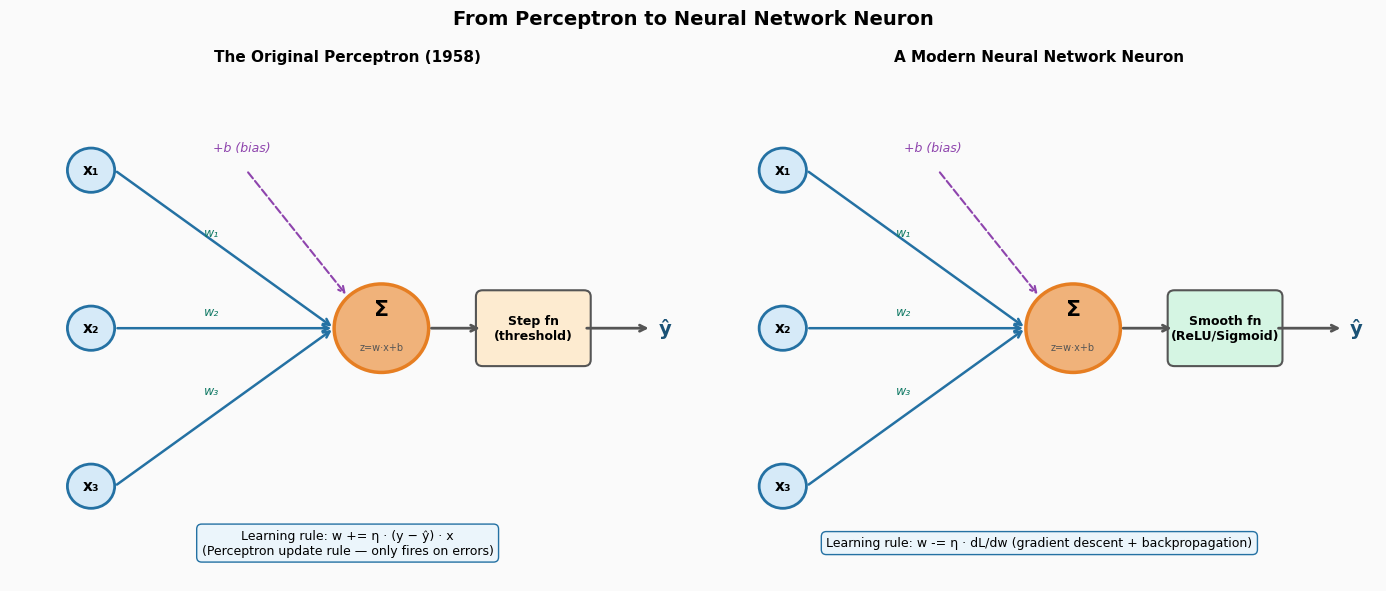

📖 The conceptual structure is identical.
   The modern neuron swaps the hard step function for a smooth activation,
   and replaces the direct update rule with backpropagation + gradient descent.
   That smooth activation is the key — it lets gradients flow, enabling backprop.


In [3]:
# ─────────────────────────────────────────────────────────────────
# THE PERCEPTRON vs THE NEURON IN A NEURAL NETWORK
# Drawing the conceptual bridge between them.
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("From Perceptron to Neural Network Neuron",
             fontsize=14, fontweight='bold')


def draw_neuron_diagram(ax, title, activation_name, activation_colour,
                        update_rule_text):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_facecolor('#FAFAFA')

    # Input nodes
    input_positions = [(1.2, 6.5), (1.2, 4.0), (1.2, 1.5)]
    input_labels    = ['x₁', 'x₂', 'x₃']
    weight_labels   = ['w₁', 'w₂', 'w₃']

    for (x, y), lbl, wlbl in zip(input_positions, input_labels, weight_labels):
        circle = plt.Circle((x, y), 0.35, color='#D6EAF8', ec='#2471A3', lw=2)
        ax.add_patch(circle)
        ax.text(x, y, lbl, ha='center', va='center', fontsize=11, fontweight='bold')
        # Arrow to neuron
        ax.annotate("", xy=(4.8, 4.0), xytext=(x + 0.35, y),
                    arrowprops=dict(arrowstyle='->', color='#2471A3', lw=1.8))
        # Weight label on arrow
        ax.text((x + 0.35 + 4.8)/2 - 0.3, (y + 4.0)/2 + 0.2,
                wlbl, fontsize=9, color='#117A65', fontstyle='italic')

    # Bias
    ax.text(3.0, 6.8, '+b (bias)', fontsize=9, color='#8E44AD', fontstyle='italic')
    ax.annotate("", xy=(5.0, 4.5), xytext=(3.5, 6.5),
                arrowprops=dict(arrowstyle='->', color='#8E44AD', lw=1.5, linestyle='dashed'))

    # Neuron body
    neuron = plt.Circle((5.5, 4.0), 0.7, color='#F0B27A', ec='#E67E22', lw=2.5)
    ax.add_patch(neuron)
    ax.text(5.5, 4.3, 'Σ', ha='center', va='center', fontsize=16, fontweight='bold')
    ax.text(5.5, 3.7, 'z=w·x+b', ha='center', va='center', fontsize=7, color='#555')

    # Activation
    act_box = mpatches.FancyBboxPatch((7.0, 3.5), 1.5, 1.0,
        boxstyle='round,pad=0.1', facecolor=activation_colour,
        edgecolor='#555', lw=1.5)
    ax.add_patch(act_box)
    ax.text(7.75, 4.0, activation_name, ha='center', va='center',
            fontsize=9, fontweight='bold')
    ax.annotate("", xy=(7.0, 4.0), xytext=(6.2, 4.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

    # Output
    ax.annotate("", xy=(9.5, 4.0), xytext=(8.5, 4.0),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))
    ax.text(9.6, 4.0, 'ŷ', ha='left', va='center', fontsize=14, fontweight='bold', color='#1A5276')

    # Update rule
    ax.text(5.0, 0.6, update_rule_text, ha='center', va='center',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB', edgecolor='#2471A3'))


draw_neuron_diagram(
    axes[0],
    "The Original Perceptron (1958)",
    activation_name='Step fn\n(threshold)',
    activation_colour='#FDEBD0',
    update_rule_text="Learning rule: w += η · (y − ŷ) · x\n(Perceptron update rule — only fires on errors)"
)

draw_neuron_diagram(
    axes[1],
    "A Modern Neural Network Neuron",
    activation_name='Smooth fn\n(ReLU/Sigmoid)',
    activation_colour='#D5F5E3',
    update_rule_text="Learning rule: w -= η · dL/dw (gradient descent + backpropagation)"
)

plt.tight_layout()
plt.savefig('perceptron_vs_neuron.png', dpi=120, bbox_inches='tight')
plt.show()

print("📖 The conceptual structure is identical.")
print("   The modern neuron swaps the hard step function for a smooth activation,")
print("   and replaces the direct update rule with backpropagation + gradient descent.")
print("   That smooth activation is the key — it lets gradients flow, enabling backprop.")

---
# PART 7 — Your Summary Notes

---

This section is written to be **copied into your personal notebook**.

---

## 📝 Note 1: Data & Features

A machine learning model does not see images, text, or objects — it sees a table of numbers called a **feature matrix X**, where each row is one training example and each column is one feature. Features can be continuous (real-valued numbers like height or salary), discrete (whole numbers like bedroom count), or categorical (labels like neighbourhood names). Categorical features must be converted to numbers using **one-hot encoding** before a model can use them. Features with very different scales must be brought to a common range using either **min-max normalisation** (scales to [0,1]) or **standardisation** (scales to mean=0, std=1). Standardisation is the most common choice in deep learning because it is robust to outliers.

**TL;DR:** *A model sees numbers. Raw data → numbers → scaled numbers → model.*

---

## 📝 Note 2: Linear Algebra Essentials

A **vector** is a list of numbers representing one data point in n-dimensional space. A **matrix** is a 2D grid of numbers — in ML, the data matrix X stacks all training examples as rows. The **dot product** of two vectors measures their alignment — large and positive when they point in the same direction, zero when perpendicular, negative when opposite. In a neural network, each neuron computes a dot product between the input vector and its weight vector; a high result means the input matches the pattern the neuron has learned to recognise. **Matrix multiplication** extends this to process an entire batch of examples through an entire layer simultaneously — it is the core computational operation of every neural network.

**TL;DR:** *All neural network layers are matrix multiplications. The dot product measures pattern alignment.*

---

## 📝 Note 3: Probability & Statistics

The **mean** (μ) is the average value; the **variance** (σ²) measures how spread out values are around the mean; the **standard deviation** (σ) is the square root of variance and has the same units as the data. The **Gaussian (Normal) distribution** — the bell curve — appears throughout ML because the Central Limit Theorem guarantees that averages of random processes tend toward it. The 68-95-99.7 rule says that 68% of a Gaussian's values lie within ±1σ of the mean, 95% within ±2σ, and 99.7% within ±3σ — giving us a practical definition of "outlier" (beyond 3σ). **Correlation** measures the linear relationship between two variables: +1 is a perfect positive relationship, 0 is no relationship, -1 is a perfect negative relationship. Highly correlated features add redundant information and should often be removed or combined.

**TL;DR:** *Mean, variance, and the Gaussian describe data. Correlation reveals relationships between features.*

---

## 📝 Note 4: Overfitting, Underfitting & Generalisation

**Underfitting** means the model is too simple — it fails even on training data (high train loss, high val loss). **Overfitting** means the model memorised training examples instead of learning the pattern — it performs brilliantly on training data but poorly on new data (low train loss, high val loss). The gap between training and validation loss is the overfitting signal. We split data into a **training set** (model learns), **validation set** (we check for overfitting during training), and **test set** (used once at the end to report real-world performance). **Regularisation** discourages overfitting by penalising complexity — L2 regularisation adds the sum of squared weights to the loss; Dropout randomly disables neurons during training.

**TL;DR:** *Train and validation loss together tell you everything. When they diverge, you are overfitting.*

---

## 📝 Note 5: Activation Functions

Without activation functions, stacking linear layers produces only a linear transformation — useless for non-linear problems. Activation functions introduce bends. **Sigmoid** squashes to (0, 1) and is used at output layers for binary classification, but suffers from vanishing gradients in hidden layers. **Tanh** squashes to (-1, +1), is zero-centred (better than sigmoid for training), but still vanishes at extremes. **ReLU** (max(0,z)) passes positive values unchanged and kills negatives — simple, fast, and the standard for hidden layers in modern networks. Its flaw is dead neurons (always negative, always zero gradient). **Leaky ReLU** fixes this with a tiny slope (0.01z) for negatives.

**Quick rule:** Hidden layers → ReLU. Binary output → Sigmoid. Multi-class output → Softmax.

---

## 📝 Note 6: The Perceptron

The **perceptron** is a single artificial neuron — the simplest learning model. It computes a weighted sum of inputs plus a bias, passes it through a step function (threshold), and outputs 0 or 1. It learns by directly correcting its weights whenever it makes a mistake: `w += η · (y - ŷ) · x`. A perceptron can only learn **linearly separable** problems — those where a single straight line can separate the classes. It cannot learn XOR. The solution is to stack multiple perceptrons with a hidden layer; the hidden layer warps the input space until the problem becomes linearly separable. Modern neural network neurons are perceptrons with smooth activation functions instead of a step function, and they learn via backpropagation instead of the direct correction rule.

**TL;DR:** *The perceptron is the atom. A neural network is a molecule. Both follow the same logic.*

---

## 📝 Note 7: Prerequisite Concept Map

```
RAW DATA
   │
   ▼  (feature engineering, one-hot encoding)
FEATURE MATRIX X  ─────────────────────────── shape: (n_examples × n_features)
   │
   ▼  (normalisation / standardisation)
SCALED FEATURES
   │
   ▼  (matrix multiplication: X @ W + B)
LINEAR TRANSFORMATION Z  ────────────────── linear algebra
   │
   ▼  (activation function: ReLU / Sigmoid / Tanh)
ACTIVATED OUTPUT A  ─────────────────────── non-linearity
   │
   ▼  (loss function)
LOSS  ───────────────────────────────────── statistics / probability
   │
   ▼  (backpropagation + gradient descent)
UPDATED WEIGHTS  ────────────────────────── converge → avoid overfitting
   │
   ▼  (evaluate on validation set)
GENERALISED MODEL  ──────────────────────── the goal
```


In [ ]:
# ─────────────────────────────────────────────────────────────────
# FINAL SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────────

print("=" * 62)
print("PREREQUISITES COMPLETE — WHAT YOU NOW KNOW")
print("=" * 62)

checklist = [
    ("Data & Features",
     "Feature types, one-hot encoding, normalisation & standardisation"),
    ("Linear Algebra",
     "Vectors, matrices, dot products, matrix multiplication"),
    ("Statistics",
     "Mean, variance, Gaussian distribution, the 68-95-99.7 rule, correlation"),
    ("Overfitting & Underfitting",
     "Train/val/test splits, the diverging loss curve, regularisation"),
    ("Activation Functions",
     "Sigmoid, Tanh, ReLU, Leaky ReLU — what they do and when to use them"),
    ("The Perceptron",
     "The original learning unit, its power, its limits, and its descendants"),
]

for topic, detail in checklist:
    print(f"\n  ✅ {topic}")
    print(f"     {detail}")

print()
print("=" * 62)
print("WHAT COMES NEXT")
print("=" * 62)
print("""
  With these foundations, you are ready to understand:
  
  🧠  Loss functions (MSE, Cross-Entropy) — how error is measured
  🧠  Gradient descent — how the model finds better weights
  🧠  Backpropagation — how gradients flow through layers
  🧠  Full neural networks — many perceptrons, many layers, real power

  All of that is in the companion notebook:
  '01_Neural_Networks_From_Scratch.ipynb'
""")